In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Importing required libraries


In [ ]:
df = pd.read_csv("ToyotaCorolla - MLR.csv")

# Loading dataset
df.head()


,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [ ]:
df.shape

# Checking dataset shape


(1436, 11)

In [ ]:
df.info()

# Checking data types and missing values


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [ ]:
df.describe()

# Statistical summary


,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


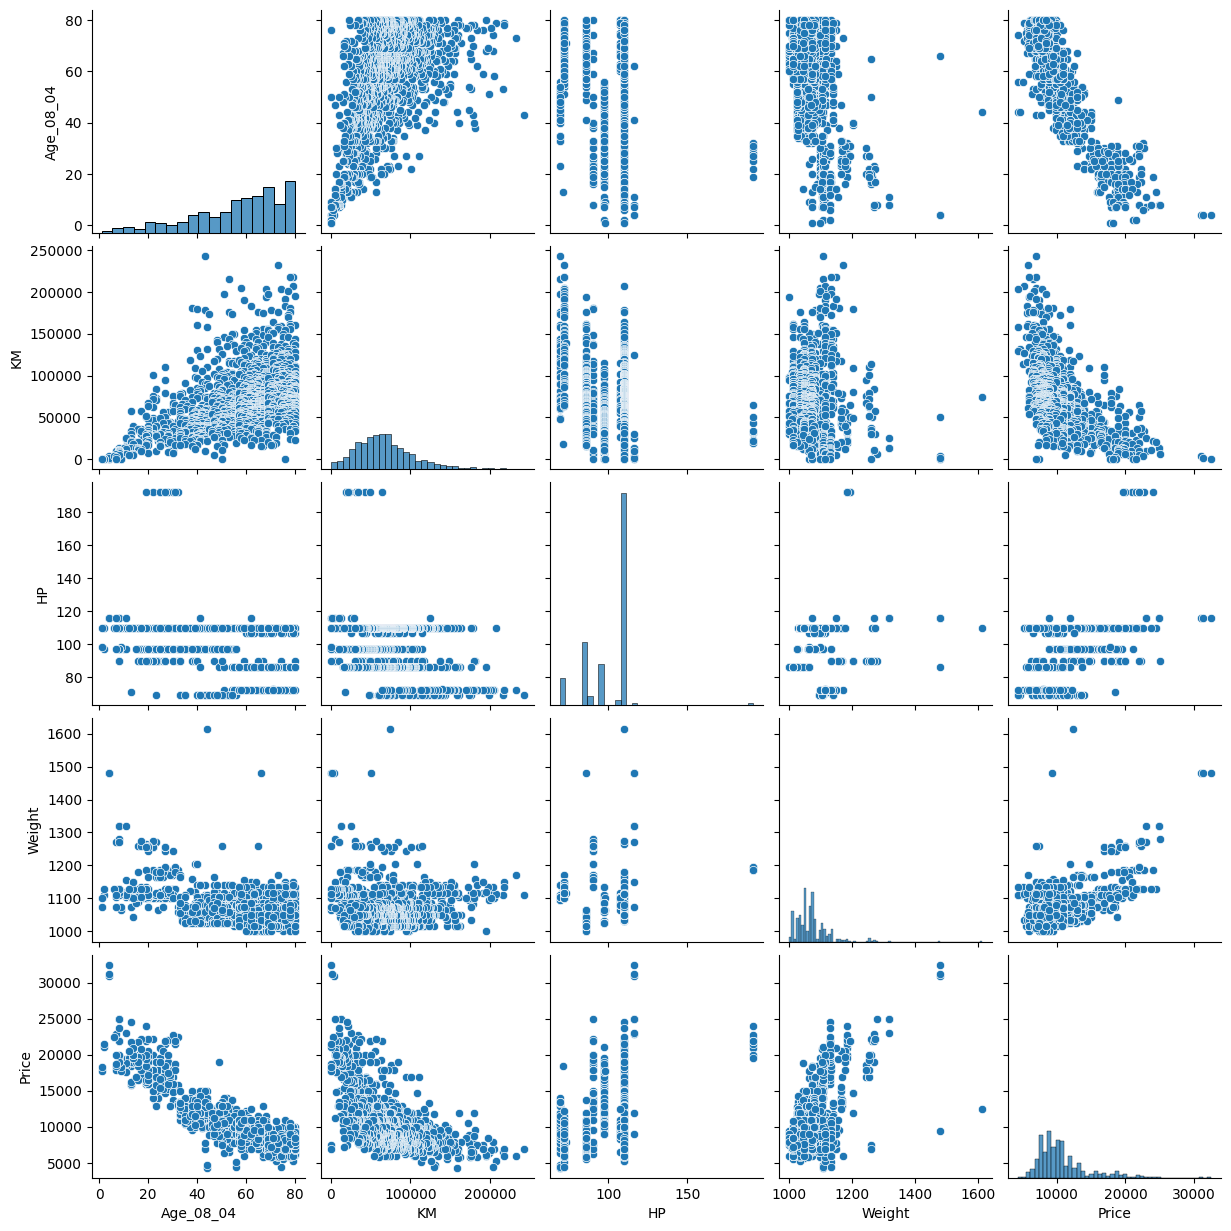

In [ ]:
sns.pairplot(df[['Age_08_04', 'KM', 'HP', 'Weight', 'Price']])
plt.show()



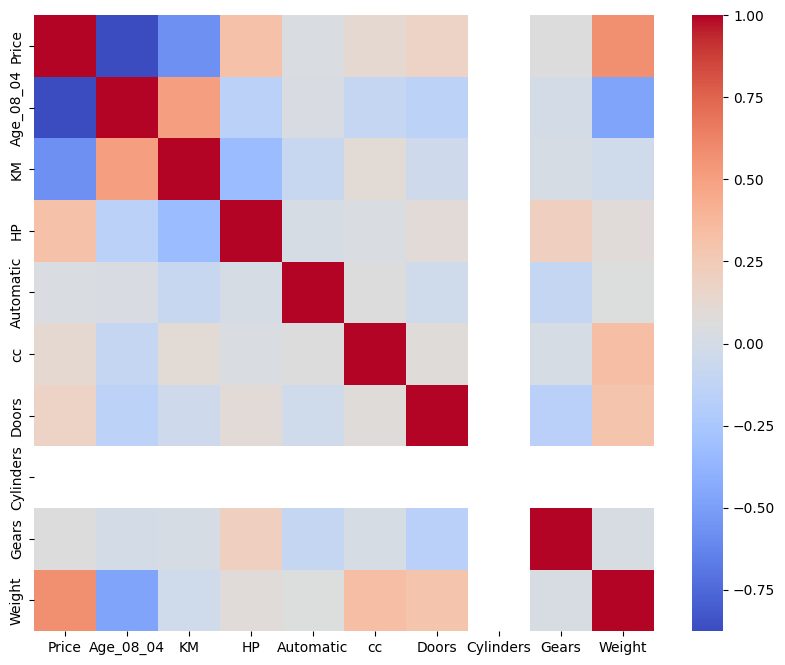

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.show()


# Correlation heatmap


In [ ]:
df = pd.get_dummies(df, drop_first=True)

df.head()   # show first 5 rows



,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,True,False
1,13750,23,72937,90,0,2000,3,4,5,1165,True,False
2,13950,24,41711,90,0,2000,3,4,5,1165,True,False
3,14950,26,48000,90,0,2000,3,4,5,1165,True,False
4,13750,30,38500,90,0,2000,3,4,5,1170,True,False


In [ ]:
X = df.drop('Price', axis=1)
y = df['Price']

X.head(), y.head()



# Separating features and target variable


(   Age_08_04     KM  HP  Automatic    cc  Doors  Cylinders  Gears  Weight  \
 0         23  46986  90          0  2000      3          4      5    1165   
 1         23  72937  90          0  2000      3          4      5    1165   
 2         24  41711  90          0  2000      3          4      5    1165   
 3         26  48000  90          0  2000      3          4      5    1165   
 4         30  38500  90          0  2000      3          4      5    1170   
 
    Fuel_Type_Diesel  Fuel_Type_Petrol  
 0              True             False  
 1              True             False  
 2              True             False  
 3              True             False  
 4              True             False  ,
 0    13500
 1    13750
 2    13950
 3    14950
 4    13750
 Name: Price, dtype: int64)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Feature scaling


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Train-Test split:")
X_train.shape, X_test.shape


Train-Test split:


((1148, 11), (288, 11))

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

print("Linear Regression model trained")


Linear Regression model trained


In [ ]:
y_pred_lr = lr.predict(X_test)

print("Linear Regression Results:")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))


Linear Regression Results:
MSE: 2203043.823143705
R2 Score: 0.834888804061108


In [ ]:
ridge = Ridge(alpha=1)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

print("Ridge Regression Results:")
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("R2 Score:", r2_score(y_test, y_pred_ridge))


Ridge Regression Results:
MSE: 2200682.0096811303
R2 Score: 0.8350658145414687


In [ ]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

print("Lasso Regression Results:")
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("R2 Score:", r2_score(y_test, y_pred_lasso))


Lasso Regression Results:
MSE: 2203012.710054413
R2 Score: 0.8348911358891582
